# Script for plotting solid lithium concentration

In [3]:
# Imports

from __future__ import annotations
from dataclasses import dataclass
from pathlib import Path
from typing import Iterable, Optional
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import AutoMinorLocator

## Functions for plotting

In [5]:
# Global plotting defaults used by all figures.
FONT = {"size": 12}
FIGSIZE = (6.3, 3.36)
CSV_SKIPROWS = 7
Y_LIMITS = (0, 30)
Y_TICKS = np.arange(0.0, 31.0, 10.0)

matplotlib.rc("font", **FONT)
plt.rcParams["axes.labelsize"] = 14


@dataclass(frozen=True)
class PlotSpec:
    model_dir: Path
    low_file: str
    high_file: str
    electrode: str
    c_rate_label: str
    panel_label: tuple[float, str]
    xbreak: tuple[float, float]
    xlim_left: tuple[float, float]
    xlim_right: tuple[float, float]
    text_left: tuple[float, float, str]
    text_right: tuple[float, float, str]
    c_rate_text: tuple[float, float, str]
    skip_first_low: int = 1
    skip_first_high: int = 1
    skip_last_low: Optional[int] = None
    skip_last_high: Optional[int] = None
    xticks_left: Optional[Iterable[float]] = None
    xticks_right: Optional[Iterable[float]] = None


def get_cycle_columns(
    df: pd.DataFrame,
    *,
    skip_first_cycles: int = 1,
    skip_last_cycles: Optional[int] = None,
) -> pd.Index:
    start = skip_first_cycles
    stop = None if skip_last_cycles is None else -skip_last_cycles
    cols = df.columns[start:stop]
    if len(cols) == 0:
        raise ValueError(
            "No cycle columns were selected. Check skip_first_cycles and skip_last_cycles."
        )
    return cols



def make_cycle_colors(n_lines: int, cmap_name: str = "berlin") -> list:
    cmap = plt.get_cmap(cmap_name, max(int(n_lines * 2.1), n_lines))
    return [cmap(i) for i in range(n_lines)]



def plot_emsi_single(
    df: pd.DataFrame,
    *,
    ax,
    skip_first_cycles: int = 1,
    skip_last_cycles: Optional[int] = None,
    xbreak: Optional[tuple[float, float]] = None,
    show_legend: bool = False,
    ylabel: str = r"$y$ [mm]",
) -> None:
    """Plot EMSI cycle data on a single axis or a pair of broken x-axes."""
    broken = isinstance(ax, (tuple, list)) and len(ax) == 2
    ax_left, ax_right = ax if broken else (ax, None)

    cycle_cols = get_cycle_columns(
        df,
        skip_first_cycles=skip_first_cycles,
        skip_last_cycles=skip_last_cycles,
    )
    colors = make_cycle_colors(len(cycle_cols))

    position_mm = pd.to_numeric(df.iloc[:, 0], errors="coerce").to_numpy(dtype=float) / 1000.0

    for cycle_number, (col, color) in enumerate(zip(cycle_cols, colors), start=1):
        concentration = pd.to_numeric(df[col], errors="coerce").to_numpy(dtype=float)

        valid = np.isfinite(position_mm) & np.isfinite(concentration)
        if not valid.any():
            continue

        x_values = concentration[valid]
        y_values = position_mm[valid]
        label = str(cycle_number) if cycle_number in {1, len(cycle_cols)} else None

        if broken:
            if xbreak is None:
                raise ValueError("xbreak must be provided when plotting on broken axes.")
            left_mask = x_values <= xbreak[0]
            right_mask = x_values >= xbreak[1]

            if left_mask.any():
                ax_left.plot(x_values[left_mask], y_values[left_mask], color=color, label=label)
            if right_mask.any():
                ax_right.plot(x_values[right_mask], y_values[right_mask], color=color, label=label)
        else:
            ax_left.plot(x_values, y_values, color=color, label=label)

    ax_left.grid(alpha=0.5)
    ax_left.set_ylabel(ylabel)
    if broken:
        ax_right.grid(alpha=0.5)
        if show_legend:
            ax_right.legend(title="Cycle nr", loc="lower right")
    elif show_legend:
        ax_left.legend(title="Cycle nr", loc="lower right")

def create_broken_x_figure() -> tuple[plt.Figure, plt.Axes, plt.Axes]:
    fig = plt.figure(figsize=FIGSIZE)
    gs = fig.add_gridspec(1, 2, width_ratios=[1, 1], wspace=0.05)
    ax_left = fig.add_subplot(gs[0, 0])
    ax_right = fig.add_subplot(gs[0, 1], sharey=ax_left)

    ax_left.yaxis.set_minor_locator(AutoMinorLocator(n=2))
    ax_left.spines["right"].set_visible(False)
    ax_right.spines["left"].set_visible(False)
    ax_right.tick_params(labelleft=False, left=False)
    ax_right.tick_params(labelleft=False, left=False, which="minor")

    d = 0.008
    kwargs_left = dict(transform=ax_left.transAxes, color="k", clip_on=False)
    kwargs_right = dict(transform=ax_right.transAxes, color="k", clip_on=False)
    ax_left.plot((1 - d, 1 + d), (-d, +d), **kwargs_left)
    ax_left.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs_left)
    ax_right.plot((-d, +d), (-d, +d), **kwargs_right)
    ax_right.plot((-d, +d), (1 - d, 1 + d), **kwargs_right)

    for axis in (ax_left, ax_right):
        axis.grid(which="minor", alpha=0.5)
        axis.xaxis.set_minor_locator(AutoMinorLocator(n=2))
        axis.set_ylim(*Y_LIMITS)
        axis.set_yticks(Y_TICKS)
        axis.set_xlabel("")

    return fig, ax_left, ax_right



def apply_plot_spec(
    fig: plt.Figure,
    ax_left: plt.Axes,
    ax_right: plt.Axes,
    spec: PlotSpec,
) -> None:

    if spec.xticks_left is not None:
        ax_left.set_xticks(list(spec.xticks_left))
    if spec.xticks_right is not None:
        ax_right.set_xticks(list(spec.xticks_right))

    ax_left.set_xlim(*spec.xlim_left)
    ax_right.set_xlim(*spec.xlim_right)

    panel_x, panel_text = spec.panel_label
    ax_left.text(panel_x, ax_left.get_ylim()[1], panel_text, weight="bold", va="top")

    fig.supxlabel(rf"$c_\text{{s}} / c_\text{{s,max}}$ ({spec.electrode})", va="bottom")
    ax_left.text(*spec.text_left, c="black")
    ax_right.text(*spec.text_right, c="black")
    ax_right.text(*spec.c_rate_text, c="black")
    fig.subplots_adjust(bottom=0.18)



def load_emsi_csv(directory: Path, filename: str, *, skiprows: int = CSV_SKIPROWS) -> pd.DataFrame:
    path = directory / filename
    return pd.read_csv(path, skiprows=skiprows)



def plot_experiment(spec: PlotSpec, output_dir: Path) -> Path:
    fig, ax_left, ax_right = create_broken_x_figure()

    df_low = load_emsi_csv(spec.model_dir, spec.low_file)
    plot_emsi_single(
        df_low,
        ax=(ax_left, ax_right),
        skip_first_cycles=spec.skip_first_low,
        skip_last_cycles=spec.skip_last_low,
        xbreak=spec.xbreak,
        show_legend=False,
    )

    df_high = load_emsi_csv(spec.model_dir, spec.high_file)
    plot_emsi_single(
        df_high,
        ax=(ax_left, ax_right),
        skip_first_cycles=spec.skip_first_high,
        skip_last_cycles=spec.skip_last_high,
        xbreak=spec.xbreak,
        show_legend=True,
    )

    apply_plot_spec(fig, ax_left, ax_right, spec)

    output_dir.mkdir(parents=True, exist_ok=True)
    output_path = output_dir / f"{Path(spec.high_file).stem}.png"
    fig.savefig(output_path, format="png", dpi=500)
    #plt.close(fig)
    return output_path


## Specify the plots

In [7]:
PLOT_SPECS = [
    PlotSpec(
        model_dir=Path("../raw_data"),
        low_file="emsli_anode_delithiation_0.5C.csv",
        high_file="emsli_anode_lithiation_0.5C.csv",
        electrode="anode",
        c_rate_label=r"C$_\text{rate}$$=0.5$",
        panel_label=(-0.0063, "(a)"),
        xbreak=(0.06, 0.6),
        xlim_left=(0.0, 0.0251),
        xlim_right=(0.6998, 0.75),
        text_left=(0.012, 20, "delithiated"),
        text_right=(0.722, 20, "lithiated"),
        c_rate_text=(0.731, 12, r"C$_\text{rate}$$=0.5$"),
        skip_first_low=3,
        skip_first_high=3,
        xticks_left=np.arange(0.0, 0.025, 0.01),
        xticks_right=np.arange(0.70, 0.75, 0.02),
    ),
    PlotSpec(
        model_dir=Path("../raw_data"),
        low_file="emsli_cathode_delithiation_0.5C.csv",
        high_file="emsli_cathode_lithiation_0.5C.csv",
        electrode="cathode",
        c_rate_label=r"C$_\text{rate}$$=0.5$",
        panel_label=(0.30, "(b)"),
        xbreak=(0.4, 0.9),
        xlim_left=(0.319, 0.3951),
        xlim_right=(0.9249, 1.005),
        text_left=(0.35, 20, "delithiated"),
        text_right=(0.95, 20, "lithiated"),
        c_rate_text=(0.975, 12, r"C$_\text{rate}$$=0.5$"),
        skip_first_low=1,
        skip_first_high=1,
        skip_last_low=3,
        skip_last_high=2,
        xticks_left=np.arange(0.32, 0.381, 0.03),
        xticks_right=np.arange(0.94, 1.1, 0.03),
    ),
    PlotSpec(
        model_dir=Path("../raw_data"),
        low_file="emsli_anode_delithiation_1C.csv",
        high_file="emsli_anode_lithiation_1C.csv",
        electrode="anode",
        c_rate_label=r"C$_\text{rate}$$=1$",
        panel_label=(-0.031, "(c)"),
        xbreak=(0.1, 0.4),
        xlim_left=(0.0, 0.1255),
        xlim_right=(0.5998, 0.73),
        text_left=(0.04, 20, "delithiated"),
        text_right=(0.651, 20, "lithiated"),
        c_rate_text=(0.681, 12, r"C$_\text{rate}$$=1$"),
        skip_first_low=1,
        skip_first_high=2,
        skip_last_low=2,
        skip_last_high=1,
    ),
    PlotSpec(
        model_dir=Path("../raw_data"),
        low_file="emsli_cathode_delithiation_1C.csv",
        high_file="emsli_cathode_lithiation_1C.csv",
        electrode="cathode",
        c_rate_label=r"C$_\text{rate}$$=1$",
        panel_label=(0.3435, "(d)"),
        xbreak=(0.6, 0.8),
        xlim_left=(0.375, 0.5003),
        xlim_right=(0.8747, 1.009),
        text_left=(0.43, 20, "delithiated"),
        text_right=(0.95, 20, "lithiated"),
        c_rate_text=(0.96, 12, r"C$_\text{rate}$$=1$"),
        skip_first_low=1,
        skip_first_high=1,
        skip_last_low=3,
        skip_last_high=2,
    ),
]


## Make the plots of in-plane solid-phase lithium concentration at 0.5C and 1C for anode and cathode, and save as PNGs
##### The electrolyte motion induced salt inhomogeneity leads to an inhomogeneous solid-phase lithium concentration that builds up incrementally over 40 cycles

Saved ..\plots\emsli_anode_lithiation_0.5C.png
Saved ..\plots\emsli_cathode_lithiation_0.5C.png
Saved ..\plots\emsli_anode_lithiation_1C.png
Saved ..\plots\emsli_cathode_lithiation_1C.png


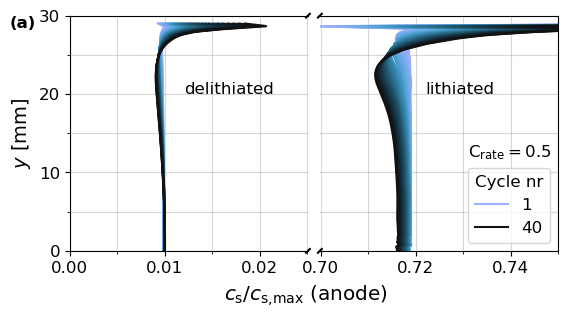

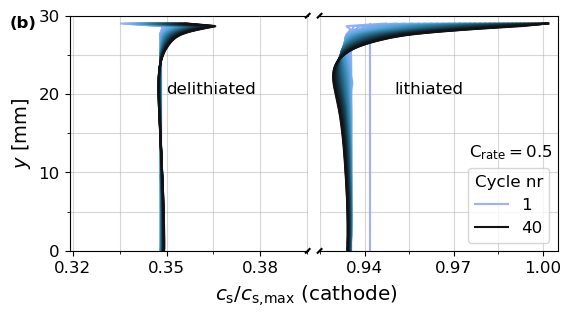

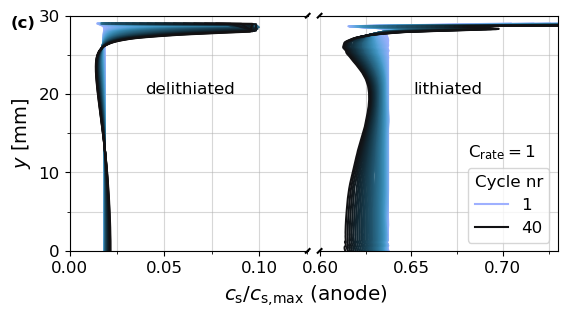

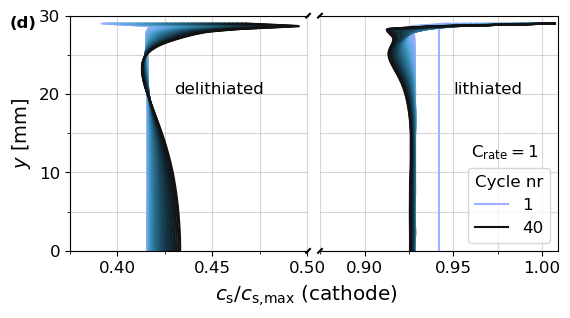

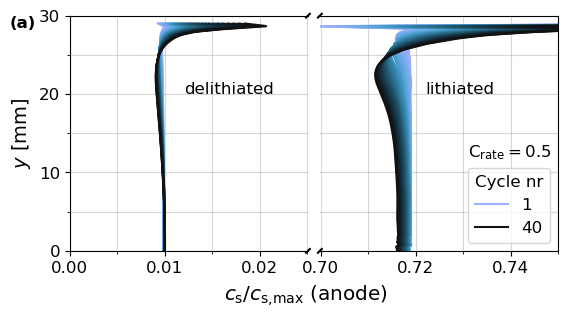

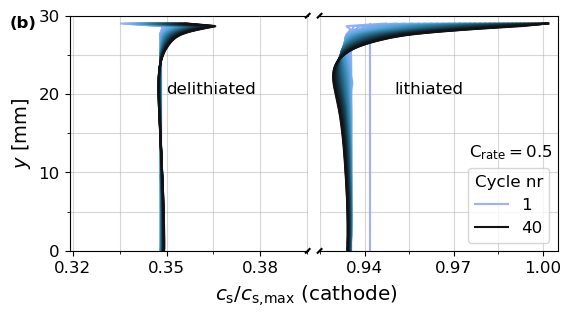

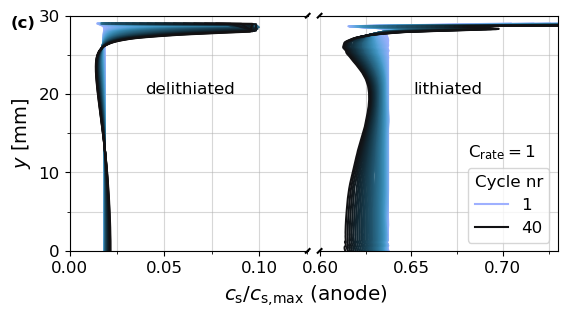

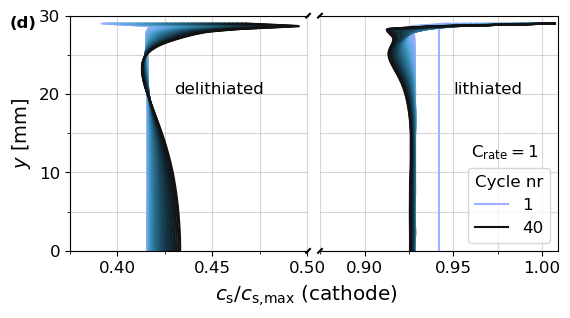

In [12]:
# Run all configured plots
def main(output_dir: Path = Path("../plots")) -> list[Path]:
    output_paths = []
    for spec in PLOT_SPECS:
        output_paths.append(plot_experiment(spec, output_dir=output_dir))
    return output_paths


if __name__ == "__main__":
    saved_paths = main()
    for saved_path in saved_paths:
        print(f"Saved {saved_path}")

saved_paths = main()